Data Preprocess

Importing the required libraries for the CNN model

In [1]:
import tensorflow as tf
import keras
from keras import layers, datasets, models
import numpy as np

Loading the data using the given code

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 [==============================] - 2s 0us/step


Reducing the pixel value by dividing x_train and x_test by 255.0. Then flattening the label values using flatten() method.

In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

y_train, y_test = y_train.flatten(), y_test.flatten()

Sequential Model

Initializing the CNN model using keras, and adding two Conv2 layers with activation function relu, and two BatchNormalization layers in the order below. Then adding a MaxPool2D layer and specifying pool size and strides as 2.

In [4]:
cnn = tf.keras.models.Sequential()

cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=[3,3], strides = [1, 1], activation='relu', padding='same', input_shape=(32, 32, 3)))
cnn.add(tf.keras.layers.BatchNormalization())
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=[3,3], strides = [1, 1], activation='relu', padding='same', input_shape=(32, 32, 3)))
cnn.add(tf.keras.layers.BatchNormalization())
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2, padding='valid'))

Repeating the steps above to add one more set of Conv2, BatchNormalization and MaxPool2D layers. Then adding a flatten layer and dropout layer with 0.2 as the rate. Finally, adding a dense layer with 128 units and relu activation function, and an output dense layer with 10 units and softmax activation function.

In [5]:
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=[3,3], strides = [1, 1], activation='relu', padding='same', input_shape=(32, 32, 3)))
cnn.add(tf.keras.layers.BatchNormalization())
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=[3,3], strides = [1, 1], activation='relu', padding='same', input_shape=(32, 32, 3)))
cnn.add(tf.keras.layers.BatchNormalization())
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2, padding='valid'))

cnn.add(tf.keras.layers.Flatten())

cnn.add(tf.keras.layers.Dropout(rate = 0.2))

cnn.add(tf.keras.layers.Dense(units=128, activation='relu'))
cnn.add(tf.keras.layers.Dense(units=10, activation='softmax'))

Training

Compiling the CNN model using the adam optimizer, and SparseCategoricalCrossentropy for loss function.

In [6]:
cnn.compile(optimizer ="adam" , loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics = [keras.metrics.SparseCategoricalAccuracy()])

Fitting the model with 25 epochs, a batch size of 32 and validation split 0.2.

In [7]:
train_history = cnn.fit(x_train, y_train, batch_size=32, epochs=25, validation_split=0.2)

Epoch 1/25


/usr/local/lib/python3.10/dist-packages/keras/src/backend.py:5729: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1250/1250 [==============================] - 22s 7ms/step - loss: 1.3228 - sparse_categorical_accuracy: 0.5342 - val_loss: 1.0662 - val_sparse_categorical_accuracy: 0.6178
Epoch 2/25
1250/1250 [==============================] - 9s 7ms/step - loss: 0.9067 - sparse_categorical_accuracy: 0.6809 - val_loss: 0.9786 - val_sparse_categorical_accuracy: 0.6645
Epoch 3/25
1250/1250 [==============================] - 8s 6ms/step - loss: 0.7593 - sparse_categorical_accuracy: 0.7318 - val_loss: 0.9720 - val_sparse_categorical_accuracy: 0.6779
Epoch 4/25
1250/1250 [==============================] - 9s 7ms/step - loss: 0.6590 - sparse_categorical_accuracy: 0.7685 - val_loss: 0.8043 - val_sparse_categorical_accuracy: 0.7236
Epoch 5/25
1250/1250 [==============================] - 8s 7ms/step - loss: 0.5830 - sparse_categorical_accuracy: 0.7957 - val_loss: 0.7187 - val_sparse_categorical_accuracy: 0.7532
Epoch 6/25
1250/1250 [==============================] - 9s 7ms/step - loss: 0.4995 - sparse_categori

Evaluating

Obtaining the evaluate history to use for graphing

In [8]:
evaluate_history = cnn.evaluate(x_test, y_test)

313/313 [==============================] - 1s 3ms/step - loss: 1.1613 - sparse_categorical_accuracy: 0.7616


Plotting the SparseCategoricalAccuracy and Loss in two separate graphs using the matplotlib library

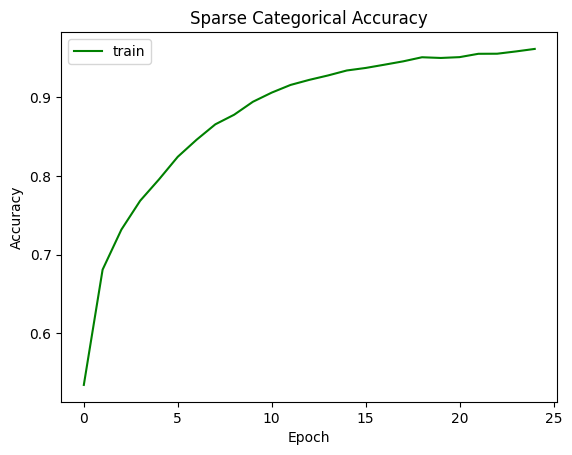

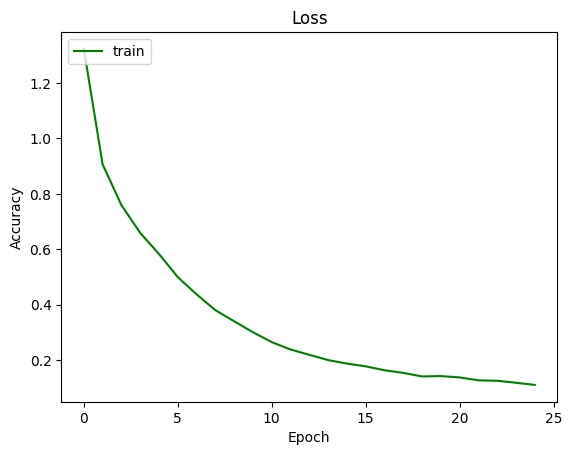

In [9]:
import matplotlib.pyplot as plt

plt.plot(train_history.history['sparse_categorical_accuracy'], color='green')
plt.title('Sparse Categorical Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train'], loc='upper left')
plt.show()

plt.plot(train_history.history['loss'], color='green')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train'], loc='upper left')
plt.show()

Calculating the predicted value of the test set, and printing the accuracy score and confusion matrix.

In [10]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = np.argmax(cnn.predict(x_test), axis = 1)

conf_mat = confusion_matrix(y_test, y_pred)
print('Confusion Matrix')
print(conf_mat)
print('Accuracy Score')
accuracy_score(y_test, y_pred)

313/313 [==============================] - 1s 2ms/step
Confusion Matrix
[[780  21  44  27  14   8   9   7  47  43]
 [  7 893   4   7   1   4  11   1  13  59]
 [ 59   4 628  69  70  64  57  32   9   8]
 [ 16   7  54 573  45 184  60  44   9   8]
 [ 14   3  53  68 700  26  53  68  11   4]
 [  9   2  33 174  28 671  27  52   2   2]
 [  7   5  42  52  17  25 838   6   4   4]
 [  5   5  22  46  47  47   7 813   3   5]
 [ 41  25   7  20   1   6   9   3 865  23]
 [ 17  65   8  18   4   4   2   8  19 855]]
Accuracy Score


0.7616

Printing the classification report

In [11]:
from sklearn.metrics import classification_report

labels = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
y_pred_classes = [np.argmax(element) for element in y_pred]
print("Classification Report: \n", classification_report(y_test, y_pred, target_names=labels))

Classification Report: 
               precision    recall  f1-score   support

    airplane       0.82      0.78      0.80      1000
  automobile       0.87      0.89      0.88      1000
        bird       0.70      0.63      0.66      1000
         cat       0.54      0.57      0.56      1000
        deer       0.76      0.70      0.73      1000
         dog       0.65      0.67      0.66      1000
        frog       0.78      0.84      0.81      1000
       horse       0.79      0.81      0.80      1000
        ship       0.88      0.86      0.87      1000
       truck       0.85      0.85      0.85      1000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.76     10000
weighted avg       0.76      0.76      0.76     10000

